# 51 - Weight Matrix Shapes

**Section:** Weight Initialization | **Prereqs:** `ANNs/NumNodes` | **Next:** `Weight Initialization/BaseWeightInitailzation.ipynb`

`nn.Linear(in, out)` stores its weight with shape **(out, in)** - transposed from
what the name suggests - because it computes `x @ W.T + b`. Storing it this way
keeps each output unit's incoming weights in one contiguous row, which is faster.

**Reading and writing weights directly**

```python
layer.weight        # a Parameter (tracked by autograd)
layer.weight.data   # the raw tensor, no autograd tracking
layer.weight.data = torch.zeros_like(layer.weight.data)   # overwrite
```

Assigning through `.data` bypasses autograd, which is what you want when setting
an initialisation and what you must *never* do inside a training step.

**Why care.** The rest of this section changes how these numbers are drawn. Being
able to read a layer's weights, histogram them, and overwrite them is the tooling
for every experiment that follows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# One Linear(10,10) layer.
model = nn.Sequential(
    nn.Linear(10,10)
)

In [3]:
# The shapes: weight is (out_features, in_features) = (10,10), bias is (10,).
# For Linear(784,64) the weight would be (64,784) - transposed from the
# constructor argument order, because the layer computes x @ W.T + b.
weights = []
for x,y in model.named_parameters():
   print(x, y.shape)

0.weight torch.Size([10, 10])
0.bias torch.Size([10])


In [6]:
# A three-layer model to experiment on.
class test_model(nn.Module):
  def __init__(self):
     super().__init__()

     self.input_layer = nn.Linear(10,10)

     self.fc1 = nn.Linear(10,10)

     self.output_layer= nn.Linear(10,10)

  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    return self.output_layer(x)

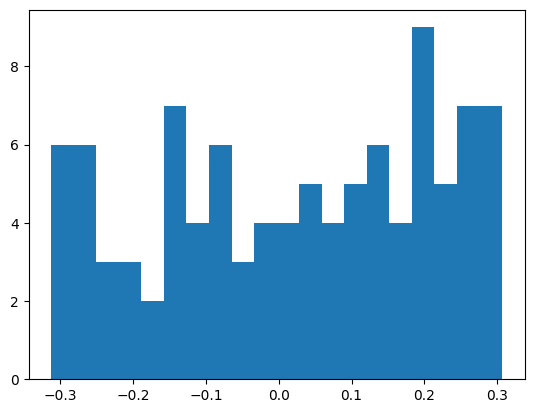

In [11]:
# The default initialisation: a narrow uniform distribution centred on zero,
# with width 1/sqrt(fan_in) - PyTorch's Kaiming-uniform default.
# This is what 'random weights' actually looks like.
test = test_model()

plt.hist(test.fc1.weight.data.flatten(), bins=20);

In [13]:
# Overwriting every weight with zeros through .data, which sidesteps autograd's
# in-place checks. Correct for initialisation; never do this inside a training
# step, where it would silently break the gradient graph.
for x,y in test.named_parameters():
  if "weight" in x:
    y.data = torch.zeros_like(y.data)

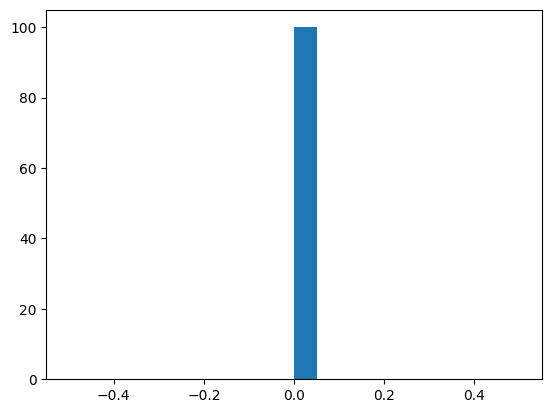

In [14]:
# The histogram is now a single spike at zero. The next notebook shows why that
# is fatal: identical weights produce identical gradients, so the units can
# never differentiate from one another.
plt.hist(test.fc1.weight.data.flatten(), bins=20);